# **MLIS Practical 08**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
To implement a Convolutional Neural Network (CNN) for classification and analysis of medical images using Python

## **Theoretical Overview**
Convolutional Neural Networks (CNNs) are deep learning architectures designed for spatial grid data such as radiological scans (X-rays, CTs, MRIs).

Unlike fully connected networks, CNNs preserve spatial structure using local receptive fields, shared kernel weights, and feature hierarchies (detecting edges $\rightarrow$ textures $\rightarrow$ pathological patterns like lung opacities).

## **Mathematical Formulation**

#### 1. **2D Convolution Operation:**
For an input image $I$ and kernel filter $K$ of size $m \times n$, the output feature map $S(i,j)$ is computed as:
$$S(i, j) = (I * K)(i, j) = \sum_{m} \sum_{n} I(i - m, j - n) K(m, n) + b$$

#### 2. **Activation Function (ReLU):**
Introduces non-linearity to learn complex pathological representations:
$$f(x) = \max(0, x)$$

#### 3. **Max Pooling (Spatial Downsampling):**
Extracts the dominant feature activation within a sliding window $R$:
$$P(i, j) = \max_{(m, n) \in R} I(i + m, j + n)$$

#### 4. **Sigmoid Output Activation:**
Maps raw dense layer outputs to a diagnostic probability score $\hat{y} \in [0, 1]$:
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

#### 5. **Binary Cross-Entropy Loss:**
$$L(y, \hat{y}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

## **Step 1: Setup + Load dataset**

In [ ]:
# Install MedMNIST for direct benchmark medical dataset loading in Google Colab
!pip install medmnist -q

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [ ]:
# Load PneumoniaMNIST (Pediatric Chest X-Ray dataset)
import medmnist
from medmnist import PneumoniaMNIST

train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset   = PneumoniaMNIST(split='val', download=True)
test_dataset  = PneumoniaMNIST(split='test', download=True)

X_train_raw, y_train_raw = train_dataset.imgs, train_dataset.labels
X_val_raw, y_val_raw     = val_dataset.imgs, val_dataset.labels
X_test_raw, y_test_raw   = test_dataset.imgs, test_dataset.labels

class_labels = {0: 'Normal', 1: 'Pneumonia'}

print("PneumoniaMNIST Dataset Summary:")
print(f"Training Set:   {X_train_raw.shape[0]} images, shape {X_train_raw.shape[1:]}")
print(f"Validation Set: {X_val_raw.shape[0]} images, shape {X_val_raw.shape[1:]}")
print(f"Testing Set:    {X_test_raw.shape[0]} images, shape {X_test_raw.shape[1:]}")

100%|██████████| 4.17M/4.17M [00:06<00:00, 666kB/s]


PneumoniaMNIST Dataset Summary:
Training Set:   4708 images, shape (28, 28)
Validation Set: 524 images, shape (28, 28)
Testing Set:    624 images, shape (28, 28)


/tmp/ipykernel_1416/2363901622.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl_idx = int(y_train_raw[i])


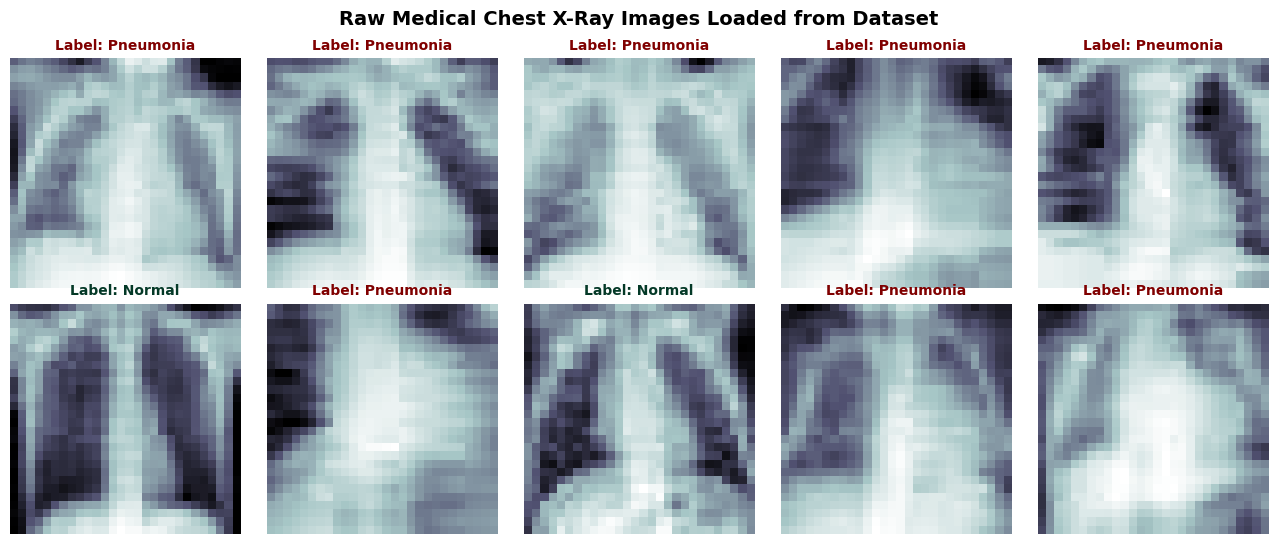

In [ ]:
# Display raw loaded medical X-ray images directly
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle("Raw Medical Chest X-Ray Images Loaded from Dataset", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = X_train_raw[i]
    lbl_idx = int(y_train_raw[i])
    label_text = class_labels[lbl_idx]

    ax.imshow(img, cmap='bone')
    ax.set_title(f"Label: {label_text}", fontsize=10, fontweight='bold', color='#800000' if lbl_idx == 1 else '#043927')
    ax.axis('off')

plt.tight_layout()
plt.show()

## **Step 2: Image Preprocessing (Reshaping + Intensity Normalization)**
Medical images are preprocessed through:
* **Pixel Intensity Normalization:** Rescaling 8-bit unsigned integer pixel values $[0, 255]$ to float values in range $[0.0, 1.0]$ for gradient stability.
* **Channel Expansion:** Adding a channel dimension to transform 2D matrices $(N, 28, 28)$ into 4D image tensors $(N, 28, 28, 1)$.
$$\mathbf{X}_{\text{normalized}} = \frac{\mathbf{X}_{\text{raw}}}{255.0}$$

In [ ]:
# 1. Rescale pixel values to range [0.0, 1.0] and add channel dimension
X_train = (X_train_raw.astype('float32') / 255.0)[..., np.newaxis]
X_val   = (X_val_raw.astype('float32') / 255.0)[..., np.newaxis]
X_test  = (X_test_raw.astype('float32') / 255.0)[..., np.newaxis]

y_train = y_train_raw.ravel()
y_val   = y_val_raw.ravel()
y_test  = y_test_raw.ravel()

print(f"Preprocessed X_train Shape: {X_train.shape} (Range: [{X_train.min():.1f}, {X_train.max():.1f}])")
print(f"Preprocessed X_test Shape:  {X_test.shape} (Range: [{X_test.min():.1f}, {X_test.max():.1f}])")

Preprocessed X_train Shape: (4708, 28, 28, 1) (Range: [0.0, 1.0])
Preprocessed X_test Shape:  (624, 28, 28, 1) (Range: [0.0, 1.0])


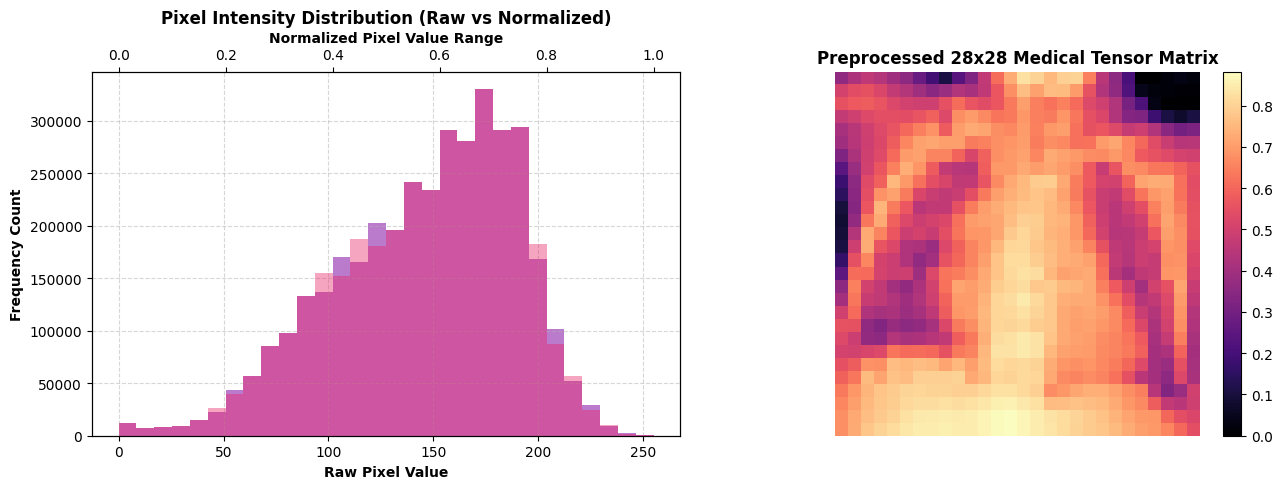

In [ ]:
# (Visualize) Histogram Comparison + Normalized Image Heatmap
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Plot pixel intensity distribution comparison
ax[0].hist(X_train_raw.ravel(), bins=30, color='#8E24AA', alpha=0.6, label='Raw Integer Pixels [0, 255]')
ax[0].set_title("Pixel Intensity Distribution (Raw vs Normalized)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Raw Pixel Value", fontweight='bold')
ax[0].set_ylabel("Frequency Count", fontweight='bold')
ax[0].grid(True, linestyle='--', alpha=0.5)

ax_norm = ax[0].twiny()
ax_norm.hist(X_train.ravel(), bins=30, color='#E91E63', alpha=0.4, label='Normalized Pixels [0.0, 1.0]')
ax_norm.set_xlabel("Normalized Pixel Value Range", fontweight='bold')

# Display preprocessed sample X-ray tensor with colorbar
im = ax[1].imshow(X_train[0].squeeze(), cmap='magma')
ax[1].set_title("Preprocessed 28x28 Medical Tensor Matrix", fontsize=12, fontweight='bold')
ax[1].axis('off')
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## **Step 3: Dataset Partitioning + Class Balance Analysis**

Analyze the distribution of classes across the Train, Validation, and Test sets to monitor diagnostic class balance.

In [ ]:
# Aggregate dataset partition statistics
train_dist = pd.Series(y_train).map(class_labels).value_counts()
val_dist   = pd.Series(y_val).map(class_labels).value_counts()
test_dist  = pd.Series(y_test).map(class_labels).value_counts()

df_splits = pd.DataFrame({
    'Train Split': train_dist,
    'Validation Split': val_dist,
    'Test Split': test_dist
})

print("Target Class Distribution across Splits")
display(df_splits)

Target Class Distribution across Splits


,Train Split,Validation Split,Test Split
Pneumonia,3494,389,390
Normal,1214,135,234


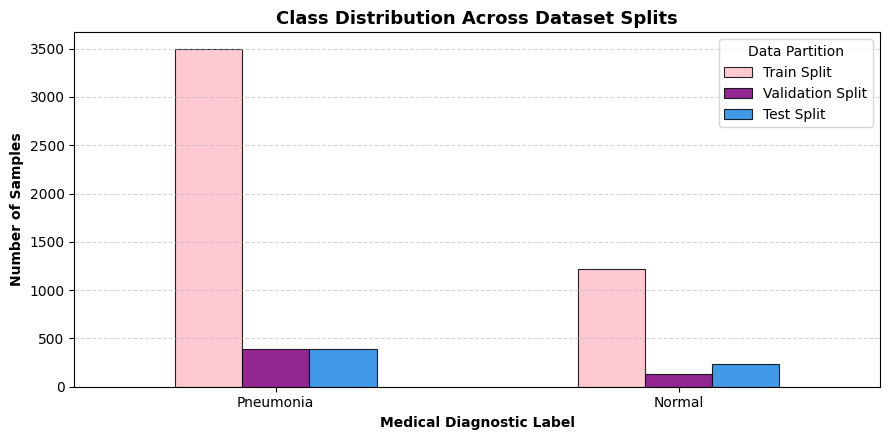

In [ ]:
# Class Distribution Bar Plot across Splits
fig, ax = plt.subplots(figsize=(9, 4.5))
df_splits.plot(kind='bar', ax=ax, color=['pink', 'purple', '#1E88E5'], edgecolor='black', linewidth=0.8, alpha=0.85)

plt.title("Class Distribution Across Dataset Splits", fontsize=13, fontweight='bold')
plt.xlabel("Medical Diagnostic Label", fontweight='bold')
plt.ylabel("Number of Samples", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Data Partition", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Step 4: CNN Architecture**
Define a 2D Convolutional Neural Network consisting of:
* **Conv2D Block 1:** 32 filters ($3 \times 3$), ReLU activation + $2 \times 2$ Max Pooling
* **Conv2D Block 2:** 64 filters ($3 \times 3$), ReLU activation + $2 \times 2$ Max Pooling
* **Dense Classifier:** Flatten layer $\rightarrow$ 64 Dense units $\rightarrow$ 0.3 Dropout regularization $\rightarrow$ Sigmoid output layer

In [ ]:
# Build CNN model using Keras Sequential API
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Dense Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN Network Architecture Summary:")
model.summary()

CNN Network Architecture Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,649 (858.00 KB)

 Trainable params: 219,649 (858.00 KB)

 Non-trainable params: 0 (0.00 B)

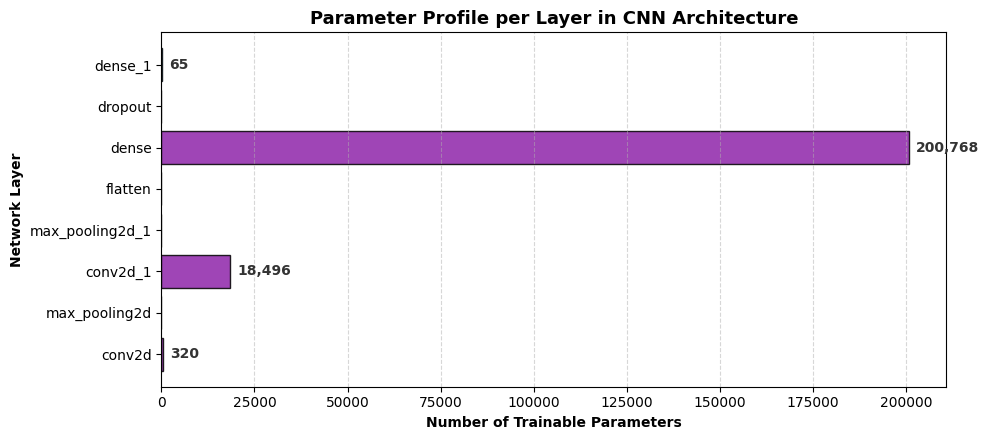

In [ ]:
# Layer Parameter Profile Visualization
layer_names = [layer.name for layer in model.layers]
layer_params = [layer.count_params() for layer in model.layers]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(layer_names, layer_params, color=['#8E24AA', '#1E88E5', '#8E24AA', '#1E88E5', '#E91E63', '#8E24AA', '#E91E63', '#1E88E5'], edgecolor='black', alpha=0.85)

for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(width + max(layer_params)*0.01, bar.get_y() + bar.get_height()/2, f'{width:,}', ha='left', va='center', fontweight='bold', color='#333333')

plt.title("Parameter Profile per Layer in CNN Architecture", fontsize=13, fontweight='bold')
plt.xlabel("Number of Trainable Parameters", fontweight='bold')
plt.ylabel("Network Layer", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Step 5: Model Training**
We train the CNN model for 15 epochs using mini-batch gradient descent (batch size = 32) and track performance against the validation set.

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8216 - loss: 0.3855 - val_accuracy: 0.9447 - val_loss: 0.1904
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9271 - loss: 0.1882 - val_accuracy: 0.9561 - val_loss: 0.1500
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9395 - loss: 0.1623 - val_accuracy: 0.9561 - val_loss: 0.1191
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9518 - loss: 0.1318 - val_accuracy: 0.9618 - val_loss: 0.1155
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9467 - loss: 0.1441 - val_accuracy: 0.9580 - val_loss: 0.1192
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9588 - loss: 0.1170 - val_accuracy: 0.9599 - val_loss: 0.0959
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9622 - loss: 0.1052 - val_accuracy: 0.9637 - val_loss: 0.0913
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9628 - loss: 0.1053 - val_accuracy: 

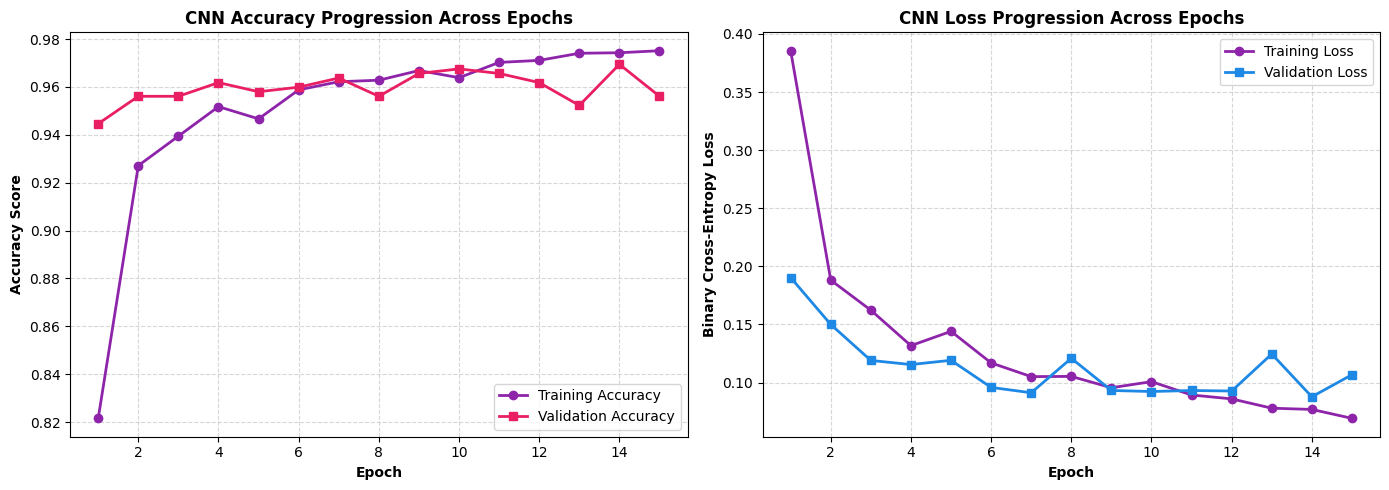

In [ ]:
# Train CNN model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# VisualizeLearning Progression Curves (Accuracy and Loss)
epochs = range(1, len(history.history['accuracy']) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy Progression
ax[0].plot(epochs, history.history['accuracy'], marker='o', color='#8E24AA', linewidth=2, label='Training Accuracy')
ax[0].plot(epochs, history.history['val_accuracy'], marker='s', color='#E91E63', linewidth=2, label='Validation Accuracy')
ax[0].set_title("CNN Accuracy Progression Across Epochs", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Epoch", fontweight='bold')
ax[0].set_ylabel("Accuracy Score", fontweight='bold')
ax[0].legend(frameon=True)
ax[0].grid(True, linestyle='--', alpha=0.5)

# Plot Loss Progression
ax[1].plot(epochs, history.history['loss'], marker='o', color='#8E24AA', linewidth=2, label='Training Loss')
ax[1].plot(epochs, history.history['val_loss'], marker='s', color='#1E88E5', linewidth=2, label='Validation Loss')
ax[1].set_title("CNN Loss Progression Across Epochs", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Epoch", fontweight='bold')
ax[1].set_ylabel("Binary Cross-Entropy Loss", fontweight='bold')
ax[1].legend(frameon=True)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Step 6: Testing & Performance Metric Evaluation**
Evaluate the model on the unseen test dataset across standard diagnostic metrics: Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [ ]:
# Generate predictions on unseen test dataset
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Test Set Quantitative Evaluation Metrics:")
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pneumonia']))

Test Set Quantitative Evaluation Metrics:
Accuracy:  87.98%
Precision: 86.04%
Recall:    96.41%
F1-Score:  90.93%

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.74      0.82       234
   Pneumonia       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.87       624
weighted avg       0.88      0.88      0.88       624



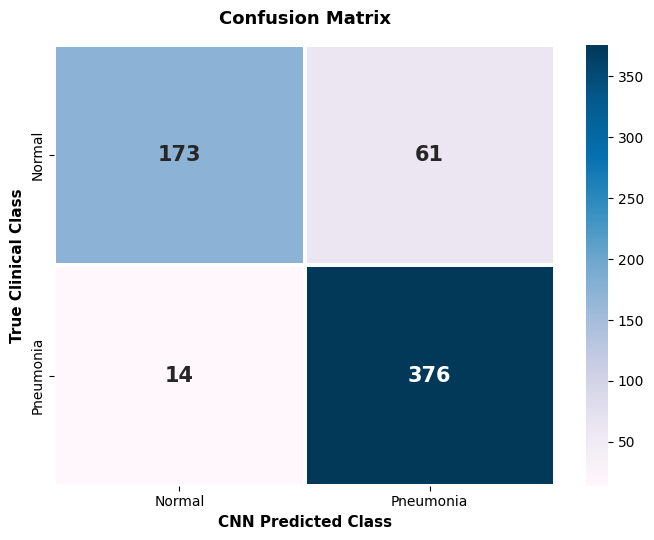

In [ ]:
# Plot Confusion Matrix

# Compute confusion matrix from test results
cm = confusion_matrix(y_test, y_pred)

# Plot standalone confusion matrix
plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='PuBu',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia'],
    cbar=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 15, "weight": "bold"}
)

plt.title("Confusion Matrix", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("True Clinical Class", fontsize=11, fontweight='bold')
plt.xlabel("CNN Predicted Class", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## **Step 7: Visual Diagnosis on Unseen Medical Test Scans**
Sample unseen medical chest X-rays are passed through the model to display the predicted class alongside the ground truth label and confidence percentage.

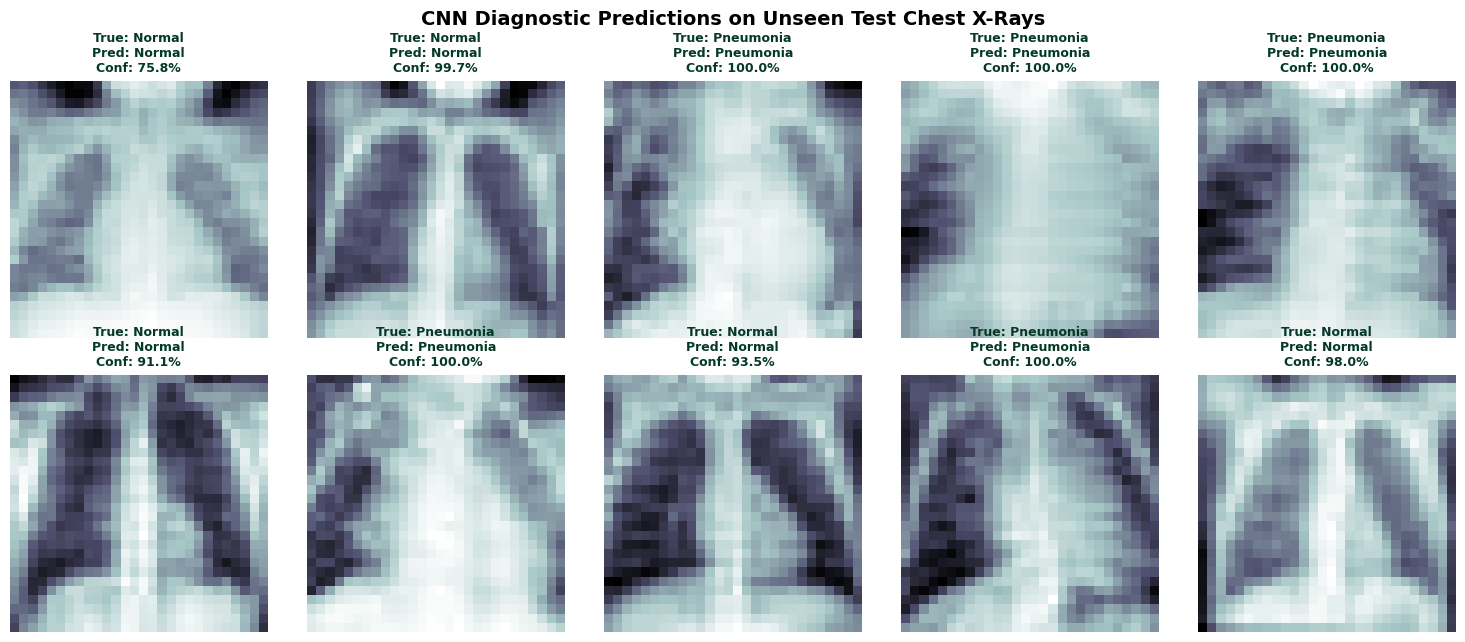

In [ ]:
# Test Sample Medical Diagnostics Visual Inspection
num_samples = 10
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
fig.suptitle("CNN Diagnostic Predictions on Unseen Test Chest X-Rays", fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_indices):
    ax = axes.flat[i]
    img = X_test[idx].squeeze()
    true_label = class_labels[y_test[idx]]
    pred_prob = y_pred_probs[idx][0]
    pred_label = class_labels[int(pred_prob > 0.5)]
    confidence = pred_prob if pred_label == 'Pneumonia' else (1.0 - pred_prob)

    # Title color: green for correct match, red for mismatch
    color_code = '#043927' if true_label == pred_label else '#800000'

    ax.imshow(img, cmap='bone')
    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence*100:.1f}%",
                 fontsize=9, fontweight='bold', color=color_code)
    ax.axis('off')

plt.tight_layout()
plt.show()

## **Conclusion**
In this practical, a Convolutional Neural Network (CNN) was successfully implemented using TensorFlow/Keras and evaluated on the PneumoniaMNIST benchmark dataset.
* Medical chest X-ray scans were loaded, preprocessed, and normalized.
* A two-block CNN architecture was trained and evaluated on unseen test scans.